### Bibliotecas

In [21]:
import pandas as pd
import numpy as np

import warnings
import os

from sklearn.model_selection import RandomizedSearchCV, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

In [22]:
# Definindo diretório
os.chdir('G:/Meu Drive/MeuDrive2/academico/3.kaggle/6.Predicting_the_Beats_per_Minute_of_Songs')

# Exibindo todas as linhas e colunas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Não exibir avisos 
warnings.filterwarnings('ignore')

### Importando os dados

In [23]:
# Dados de treino
train = pd.read_csv("train.csv")

# Dados de teste
test = pd.read_csv("test.csv")

# Submissão
sample_submission = pd.read_csv("sample_submission.csv")

In [24]:
# Remover a coluna id
train = train.drop(columns=["id"])

In [25]:
# Primeiras observações
train.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


### Análise explorativa

In [26]:
# Dimensão dos dados de treino
train.shape

(524164, 10)

In [27]:
# Verificando se há dados faltantes
train.isna().sum()

RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64

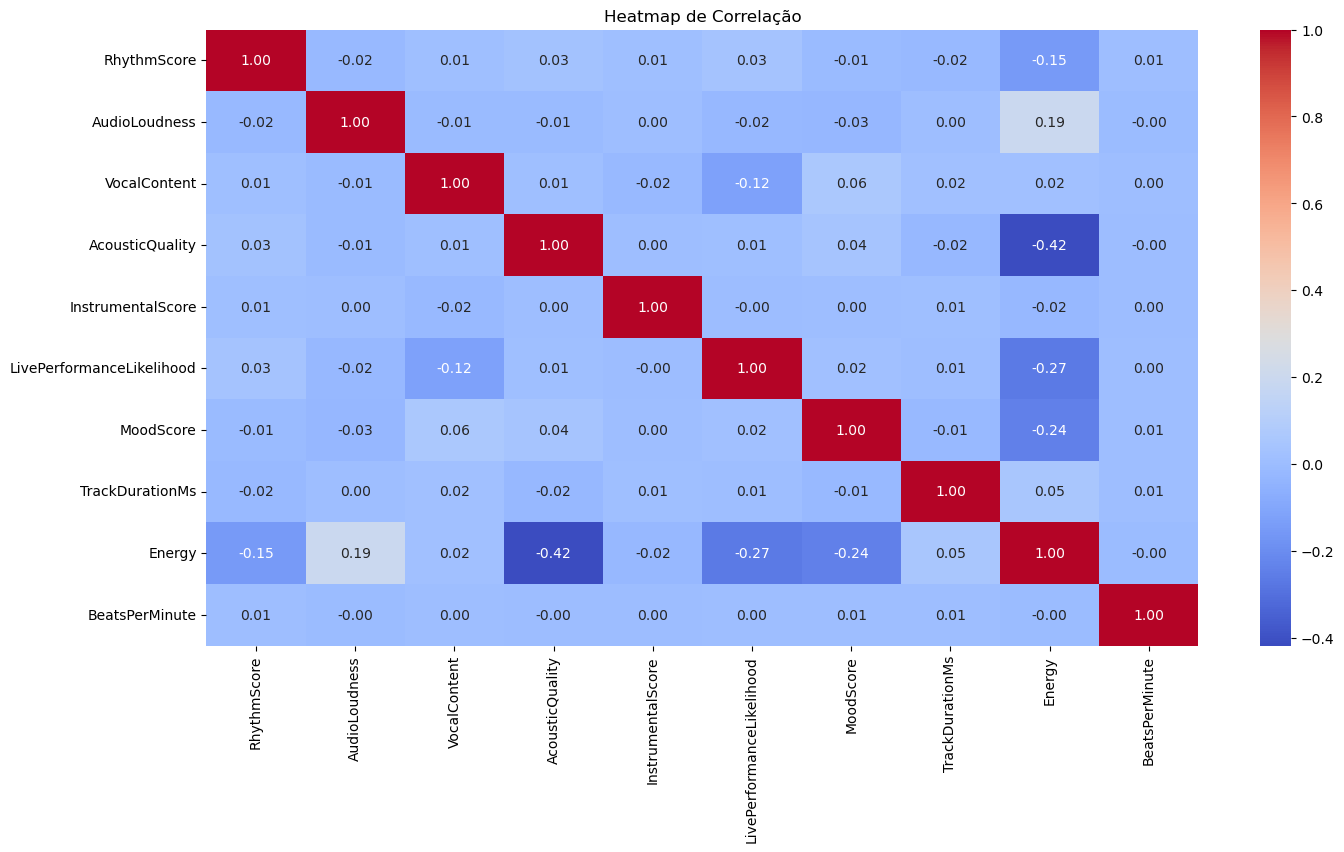

In [28]:
# Correlação entre as variáveis
plt.figure(figsize=(16,8))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de Correlação")
plt.show()

### Separando em treino e teste

In [29]:
# Separando os dados
from sklearn.model_selection import train_test_split

target = "BeatsPerMinute"
X = train.drop(columns=[target])
y = train[target]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, # Conjunto de validação
                                                      random_state=42, 
                                                      shuffle=True)

### Criação de variáveis

##### LiveEnergyInteraction

In [30]:
X_train['LiveEnergyInteraction'] = X_train['Energy']*X_train['LivePerformanceLikelihood']
X_valid['LiveEnergyInteraction'] = X_valid['Energy']*X_valid['LivePerformanceLikelihood']

In [41]:
X_train.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,LiveEnergyInteraction
129122,0.781405,-4.356901,0.023500,0.000005,0.000001,0.040420,0.682512,241538.2567,0.541800,0.021900
493077,0.532378,-8.908300,0.023500,0.012917,0.032240,0.076140,0.483868,180583.7425,0.994667,0.075734
457814,0.912855,-14.355710,0.120433,0.372479,0.127346,0.024300,0.440126,291223.4702,0.566267,0.013760
411024,0.471765,-5.637425,0.043413,0.504548,0.162065,0.065687,0.485008,313870.0566,0.492067,0.032322
397112,0.975000,-11.681864,0.031886,0.086502,0.000001,0.308907,0.682415,243435.6405,0.453667,0.140141


### Outliers

In [31]:
# Criar cópias para não sobrescrever original
X_train_out = X_train.copy()
X_valid_out = X_valid.copy()

# Percorrer todas as colunas numéricas
for col in X_train_out.select_dtypes(include='number').columns:
    lower = X_train_out[col].quantile(0.01)
    upper = X_train_out[col].quantile(0.99)
    
    # Winsorizing no treino
    X_train_out[col] = X_train_out[col].clip(lower, upper)
    
    # Aplicar MESMOS limites no valid
    X_valid_out[col] = X_valid_out[col].clip(lower, upper)

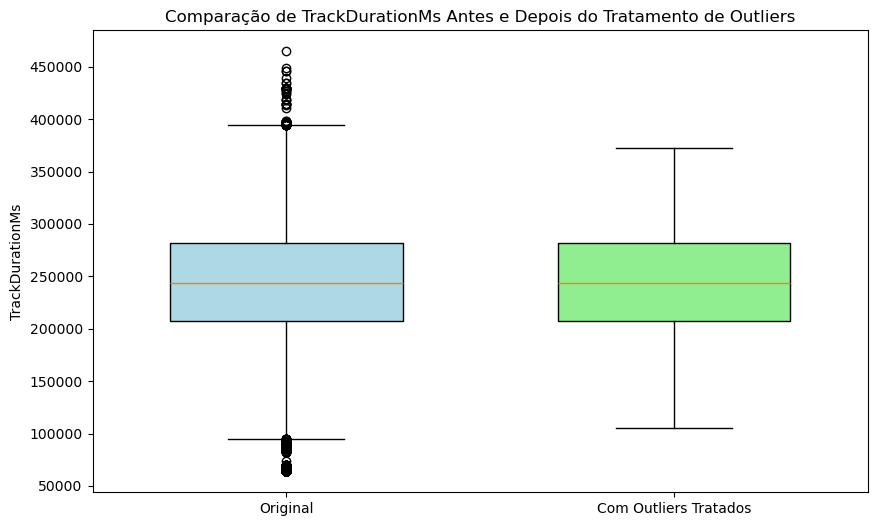

In [32]:
import matplotlib.pyplot as plt

# Criar figura
plt.figure(figsize=(10,6))

# Boxplot do original
plt.boxplot(X_train['TrackDurationMs'], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"))
# Boxplot do Winsorizado
plt.boxplot(X_train_out['TrackDurationMs'], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"))

# Configurar eixos
plt.xticks([1, 2], ['Original', 'Com Outliers Tratados'])
plt.ylabel('TrackDurationMs')
plt.title('Comparação de TrackDurationMs Antes e Depois do Tratamento de Outliers')

plt.show()

### Padronizando os dados

In [33]:
from sklearn.preprocessing import MinMaxScaler

# Instancia o scaler
scaler = MinMaxScaler()

# Aprende os limites (min e max) somente com X_train
scaler.fit(X_train_out)

# Transforma X_train e X_val com base nos limites do treino
X_train_scaled = scaler.transform(X_train_out)
X_valid_scaled = scaler.transform(X_valid_out)

# Voltando para o formato DataFrame
X_train_scaled = pd.DataFrame(scaler.transform(X_train_out), 
                              columns=X_train_out.columns, 
                              index=X_train_out.index)

X_valid_scaled = pd.DataFrame(scaler.transform(X_valid_out), 
                            columns=X_valid_out.columns, 
                            index=X_valid_out.index)

### Previsão

##### LightGBM

In [14]:
"""from lightgbm import LGBMRegressor

# Modelo base
lgbm = LGBMRegressor(
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

# Espaço de hiperparâmetros (grid completo)
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [-1, 3, 5, 7],       # -1 = sem limite
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0]
}

# Validação cruzada
cv = KFold(n_splits=5, 
           shuffle=True, 
           random_state=42)

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE
    cv=cv,
    verbose=3,
    n_jobs=2
)

# Treinar busca
grid_search.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor RMSE CV:", -grid_search.best_score_)

# Avaliação no conjunto de validação
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_valid_scaled)

rmse_val = np.sqrt(mean_squared_error(y_valid, y_pred))
print("Validation RMSE:", f"{rmse_val:.5f}")"""

#Melhores parâmetros (Com tratamento de outliers): {'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 200, 'subsample': 0.7}
#Melhor RMSE CV (Com tratamento de outliers): 26.464318527450565
#Validation RMSE (Com tratamento de outliers): 26.43743

'from lightgbm import LGBMRegressor\n\n# Modelo base\nlgbm = LGBMRegressor(\n    random_state=42,\n    n_jobs=2,\n    verbosity=-1\n)\n\n# Espaço de hiperparâmetros (grid completo)\nparam_grid = {\n    "n_estimators": [200, 500, 800],\n    "max_depth": [-1, 3, 5, 7],       # -1 = sem limite\n    "learning_rate": [0.01, 0.05, 0.1],\n    "subsample": [0.7, 0.8, 1.0]\n}\n\n# Validação cruzada\ncv = KFold(n_splits=5, \n           shuffle=True, \n           random_state=42)\n\ngrid_search = GridSearchCV(\n    estimator=lgbm,\n    param_grid=param_grid,\n    scoring="neg_root_mean_squared_error",  # RMSE\n    cv=cv,\n    verbose=3,\n    n_jobs=2\n)\n\n# Treinar busca\ngrid_search.fit(X_train_scaled, y_train)\n\nprint("Melhores parâmetros:", grid_search.best_params_)\nprint("Melhor RMSE CV:", -grid_search.best_score_)\n\n# Avaliação no conjunto de validação\nbest_model = grid_search.best_estimator_\n\ny_pred = best_model.predict(X_valid_scaled)\n\nrmse_val = np.sqrt(mean_squared_error(y_valid

In [40]:
# Modelo final com os melhores hiperparâmetros encontrados
"""best_params = {
    'learning_rate': 0.01,
    'max_depth': -1,
    'n_estimators': 200,
    'subsample': 0.7,
    'random_state': 42,
    'n_jobs': 2,
    'verbosity': -1
}

final_lgbm = LGBMRegressor(**best_params)

# Treinar no conjunto de treino
final_lgbm.fit(X_train_scaled, y_train)

# Fazer previsões no conjunto de validação
y_pred = final_lgbm.predict(X_valid_scaled)

# Calcular RMSE
rmse_val = np.sqrt(mean_squared_error(y_valid, y_pred))
print("Validation RMSE:", f"{rmse_val:.5f}")"""

# Validation RMSE: 26.43743

'best_params = {\n    \'learning_rate\': 0.01,\n    \'max_depth\': -1,\n    \'n_estimators\': 200,\n    \'subsample\': 0.7,\n    \'random_state\': 42,\n    \'n_jobs\': 2,\n    \'verbosity\': -1\n}\n\nfinal_lgbm = LGBMRegressor(**best_params)\n\n# Treinar no conjunto de treino\nfinal_lgbm.fit(X_train_scaled, y_train)\n\n# Fazer previsões no conjunto de validação\ny_pred = final_lgbm.predict(X_valid_scaled)\n\n# Calcular RMSE\nrmse_val = np.sqrt(mean_squared_error(y_valid, y_pred))\nprint("Validation RMSE:", f"{rmse_val:.5f}")'

### Teste

In [15]:
# Removendo a coluna id do X_test (mas vamos precisar dela para o submission)
ids = test["id"].copy()
X_test = test.drop(columns=["id"])

In [16]:
# Criando LiveEnergyInteraction
X_test['LiveEnergyInteraction'] = X_test['Energy']*X_test['LivePerformanceLikelihood']

In [17]:
# Outliers
# Criar cópia do teste para não sobrescrever
X_test_out = X_test.copy()

# Aplicar winsorizing usando os limites do treino
for col in X_train_out.select_dtypes(include='number').columns:
    lower = X_train_out[col].quantile(0.01)
    upper = X_train_out[col].quantile(0.99)
    
    X_test_out[col] = X_test_out[col].clip(lower, upper)

In [18]:
# Padronização
X_test_scaled = scaler.transform(X_test_out)

# Voltando para DataFrame
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_out.columns,
    index=X_test_out.index
)

In [19]:
# Prever no conjunto de teste
y_test_pred = final_lgbm.predict(X_test_scaled)

In [20]:
# Criar DataFrame de submissão
submission = pd.DataFrame({
    "id": ids,         # ids do conjunto de teste
    "y": y_test_pred   # substituir "y" pelo nome da target da competição, se necessário
})

# Salvar em CSV
submission.to_csv("final_lgbm_pt2.csv", index=False)